# 🩺 Diabetes Prediction com XGBoost (Kaggle Playground S5E12)

Este notebook aborda o **desafio de previsão de diabetes** da série *Kaggle Playground Series S5E12*, em que o objetivo é prever a **probabilidade de um paciente ser diagnosticado com diabetes** a partir de variáveis tabulares sintéticas inspiradas em dados reais.

## 🎯 Objetivo do Projeto

- Explorar o dataset da competição, entendendo a distribuição da variável alvo `diagnosed_diabetes` e das principais features.
- Construir modelos de classificação binária (baseline com Regressão Logística / Random Forest).
- Treinar e ajustar um modelo de **XGBoost** focado em maximizar a **AUC‑ROC**, métrica oficial da competição.
- Comparar o desempenho entre modelos e interpretar quais variáveis mais contribuem para a previsão de diabetes.
- Gerar um arquivo de submissão (`submission.csv`) no formato esperado pelo Kaggle: `id, diagnosed_diabetes` com probabilidades entre 0 e 1.

## 🧱 Estrutura do Notebook

1. **Bibliotecas utilizadas**
2. **Contexto e Carregamento dos Dados**
3. **Análise Exploratória (EDA)**
4. **Modelos Baseline (Logistic Regression & XGBoost)**
5. **Modelo Otimizado XGBoost + Tuning de Hiperparâmetros + Balanceamento**
6. **Conclusões e etapas futuras**

---

# 1. BIBLIOTECAS:

Nesta seção são importadas as principais bibliotecas usadas ao longo do projeto, incluindo ferramentas para manipulação de dados (Pandas, NumPy), visualização (Matplotlib, Seaborn) e modelagem (Scikit‑learn, XGBoost). Também são definidos estilos gráficos e configurações iniciais para garantir reprodutibilidade e um ambiente de trabalho consistente.

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint, uniform
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
%matplotlib inline
sns.set(style="whitegrid", palette="husl")
plt.style.use("default")
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [4]:
from xgboost import XGBClassifier

# 2. DATASET:

Aqui são carregados os arquivos train.csv e test.csv da competição, bem como exploradas suas dimensões, tipos de variáveis e presença de valores ausentes. O objetivo é entender a estrutura básica dos dados, identificar a variável alvo diagnosed_diabetes e preparar o terreno para a análise exploratória.

In [5]:
train_df = pd.read_csv("train.csv")
test_df  = pd.read_csv("test.csv")

In [6]:
# SHAPE DO TRAINING SET:
print(f"Shape do dataset: {train_df.shape}")
print(f"   • {train_df.shape[0]} registros")
print(f"   • {train_df.shape[1]} colunas")

Shape do dataset: (700000, 26)
   • 700000 registros
   • 26 colunas


In [19]:
# 5 PRIMEIRAS LINHAS DO TRAINING SET:
train_df.head().T

,0,1,2,3,4
id,0,1,2,3,4
age,31,50,32,54,54
alcohol_consumption_per_week,1,2,3,3,1
physical_activity_minutes_per_week,45,73,158,77,55
diet_score,7.7,5.7,8.5,4.6,5.7
sleep_hours_per_day,6.8,6.5,7.4,7.0,6.2
screen_time_hours_per_day,6.1,5.8,9.1,9.2,5.1
bmi,33.4,23.8,24.1,26.6,28.8
waist_to_hip_ratio,0.93,0.83,0.83,0.83,0.9
systolic_bp,112,120,95,121,108


In [8]:
# DTYPES DO TRAINING SET:
print(f"Tipos de dados:")
print(train_df.dtypes)

Tipos de dados:
id                                      int64
age                                     int64
alcohol_consumption_per_week            int64
physical_activity_minutes_per_week      int64
diet_score                            float64
sleep_hours_per_day                   float64
screen_time_hours_per_day             float64
bmi                                   float64
waist_to_hip_ratio                    float64
systolic_bp                             int64
diastolic_bp                            int64
heart_rate                              int64
cholesterol_total                       int64
hdl_cholesterol                         int64
ldl_cholesterol                         int64
triglycerides                           int64
gender                                 object
ethnicity                              object
education_level                        object
income_level                           object
smoking_status                         object
employment_status 

# 3. ANÁLISE EXPLORATÓRIA DE DADOS (EDA):

Nesta etapa é realizada a análise exploratória das variáveis numéricas e categóricas, incluindo distribuições, outliers e correlações com o alvo. O foco é identificar padrões relevantes para o risco de diabetes e selecionar as features mais informativas para os modelos, construindo gráficos como histogramas, boxplots e proporções por categoria.

In [16]:
# DESCRIÇÃO ESTATÍSTICA DO TRAINING SET:
print(f"Descrição estatística:")
train_df.describe().T

Descrição estatística:


,count,mean,std,min,25%,50%,75%,max
id,700000.0,349999.500000,202072.738554,0.00,174999.75,349999.50,524999.25,699999.00
age,700000.0,50.359734,11.655520,19.00,42.00,50.00,58.00,89.00
alcohol_consumption_per_week,700000.0,2.072411,1.048189,1.00,1.00,2.00,3.00,9.00
physical_activity_minutes_per_week,700000.0,80.230803,51.195071,1.00,49.00,71.00,96.00,747.00
diet_score,700000.0,5.963695,1.463336,0.10,5.00,6.00,7.00,9.90
sleep_hours_per_day,700000.0,7.002200,0.901907,3.10,6.40,7.00,7.60,9.90
screen_time_hours_per_day,700000.0,6.012733,2.022707,0.60,4.60,6.00,7.40,16.50
bmi,700000.0,25.874684,2.860705,15.10,23.90,25.90,27.80,38.40
waist_to_hip_ratio,700000.0,0.858766,0.037980,0.68,0.83,0.86,0.88,1.05
systolic_bp,700000.0,116.294193,11.010390,91.00,108.00,116.00,124.00,163.00


In [17]:
# VALORES NULOS DO TRAINING SET:
print(f"Valores nulos por coluna:")
print(train_df.isnull().sum())

Valores nulos por coluna:
id                                    0
age                                   0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
smoking_status                        0
employment_status                     0
family_history_diabetes               0
hypertension_history                  0
cardiovascular

## 3.1. TARGET:

In [ ]:
# DISTRIBUIÇÃO DO TARGET:
print(f"Distribuição da variável alvo:")
train_df['diagnosed_diabetes'].value_counts()

Distribuição da variável alvo:


diagnosed_diabetes
1.0    436307
0.0    263693
Name: count, dtype: int64

In [27]:
# DISTRIBUIÇÃO DO TARGET:
print(f"Porcentagem de cada classe:")
train_df['diagnosed_diabetes'].value_counts(normalize=True)*100

Porcentagem de cada classe:


diagnosed_diabetes
1.0    62.329571
0.0    37.670429
Name: proportion, dtype: float64

In [ ]:
# VISUALIZAÇÃO DA DISTRIBUIÇÃO DO TARGET:
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x="diagnosed_diabetes", palette="husl")
plt.title("Distribuição da variável alvo (diagnosed_diabetes)")
plt.xlabel("diagnosed_diabetes (0 = sem diagnóstico, 1 = com diagnóstico)")
plt.ylabel("Frequência")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

O target é binária, indicando se o paciente foi diagnosticado com diabetes (1) ou não (0).  
A distribuição é moderadamente desbalanceada, com aproximadamente **62% de positivos** (diabetes) e **38% de negativos**.  

Esse desbalanceamento não é extremo, mas é suficiente para justificar o uso de **AUC‑ROC** como métrica principal, pois ela é menos sensível à proporção entre classes do que a acurácia simples.

## 3.2. FEATURES NUMÉRICAS:

In [54]:
# FEATURES NUMÉRICAS MENOS O TARGET E O ID:
num_cols = train_df.select_dtypes(include=["int64","float64"]).columns.drop(["diagnosed_diabetes", "id"])
num_cols

Index(['age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history'],
      dtype='object')

* Existem algumas features que embora sejam classificadas como *numéricas* no dataset, elas são *categóricas*. E por isso serão excluídas de `'num_col'`. São elas: `'family_history_diabetes'`, `'hypertension_history'`, `'cardiovascular_history'` e `'alcohol_consumption_per_week'`.

In [55]:
num_cols = num_cols.drop(["cardiovascular_history",
                          "hypertension_history",
                          "family_history_diabetes",
                          "alcohol_consumption_per_week"])
num_cols

Index(['age', 'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides'],
      dtype='object')

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data=train_df, x=col, kde=True, bins=30, color="purple")
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

- Variáveis como `age`, `bmi`, `waist_to_hip_ratio`, `systolic_bp`, `diastolic_bp`,`heart_rate`, `cholesterol_total` e `hdl_cholesterol` apresentam distribuições aproximadamente normais.

- Algumas variáveis relacionadas a comportamento (ex.: `physical_activity_minutes_per_week`, `screen_time_hours_per_day`) são assimétricas, indicando grupos menores de pacientes com valores extremos (muito sedentários ou muito ativos).

In [61]:
# CORRELAÇÃO DAS FEATURES NUMÉRICAS COM O TARGET:
corr = train_df[num_cols.tolist() + ["diagnosed_diabetes"]].corr()["diagnosed_diabetes"].sort_values(ascending=False)
corr

diagnosed_diabetes                    1.000000
age                                   0.161162
systolic_bp                           0.107132
bmi                                   0.105580
ldl_cholesterol                       0.102771
triglycerides                         0.090635
cholesterol_total                     0.088112
waist_to_hip_ratio                    0.081050
diastolic_bp                          0.036271
heart_rate                            0.023865
screen_time_hours_per_day             0.018213
sleep_hours_per_day                   0.003509
diet_score                           -0.050119
hdl_cholesterol                      -0.053231
physical_activity_minutes_per_week   -0.169789
Name: diagnosed_diabetes, dtype: float64

In [ ]:
# SELECIONAR AS FEEATURES NUMÉRICAS COM MAIOR CORRELAÇÃO EM MÓDULO > 0.105 COM O TARGET:
strong_corr = corr[abs(corr) > 0.105].index.drop("diagnosed_diabetes")

# EXIBIR FEATURE SELECIONADA E O VALOR DA CORRELAÇÃO:
for feature in strong_corr:
    print(f"{feature}: {corr[feature]:.3f}")

age: 0.161
systolic_bp: 0.107
bmi: 0.106
physical_activity_minutes_per_week: -0.170


In [ ]:
# BOXPLOTS DAS FEATURES NUMÉRICAS COM MAIOR CORRELAÇÃO COM O TARGET:
for feature in strong_corr:
    plt.figure(figsize=(5,4))
    sns.boxplot(data=train_df, x="diagnosed_diabetes", y=feature, palette="Set2")
    plt.title(f"Boxplot de {feature} por diagnosed_diabetes")
    plt.xlabel("diagnosed_diabetes (0 = sem diagnóstico, 1 = com diagnóstico)")
    plt.ylabel(feature)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

Foram selecionadas as variáveis numéricas com **correlação em módulo maior que 0,105** em relação ao alvo `diagnosed_diabetes`. As principais observações dos boxplots são:

- **age**: pacientes diagnosticados com diabetes tendem a ser mais velhos, com mediana claramente maior que a do grupo sem diabetes.  
- **systolic_bp**: a pressão sistólica é, em média, mais alta no grupo com diabetes, sugerindo associação entre hipertensão e risco de diabetes.  
- **bmi**: o IMC dos pacientes com diabetes é deslocado para valores mais altos, reforçando o papel do excesso de peso como fator de risco.  
- **physical_activity_minutes_per_week**: embora haja muitos outliers, o grupo com diabetes apresenta tendência a praticar menos atividade física semanalmente.


## 3.3. FEATURES CATEGÓRICAS:

In [ ]:
# SELEÇÃO DAS FEATURES CATEGÓRICAS:
cat_cols = list(train_df.select_dtypes(include=['object']).columns) + ['family_history_diabetes',
                                                                       'hypertension_history',
                                                                       'cardiovascular_history',
                                                                       'alcohol_consumption_per_week']

# UNICIDADE:
cat_cols = list(dict.fromkeys(cat_cols))
cat_cols

['gender',
 'ethnicity',
 'education_level',
 'income_level',
 'smoking_status',
 'employment_status',
 'family_history_diabetes',
 'hypertension_history',
 'cardiovascular_history',
 'alcohol_consumption_per_week']

Aqui foi adicionado manualmente as features binárias/inteiras que são categorias (que foram listadas na etapa anterior 3.2), garantindo unicidade da lista.

C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_13780\105825291.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=col, palette="husl")


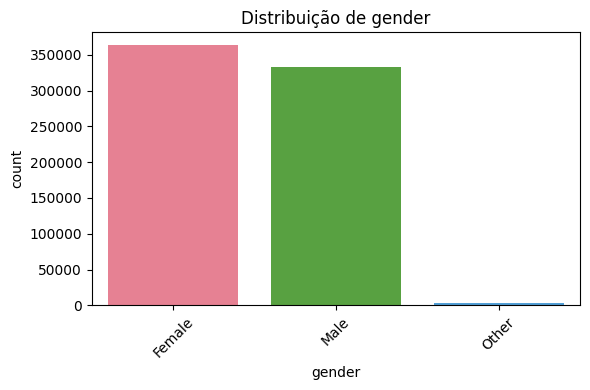

C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_13780\105825291.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=col, palette="husl")


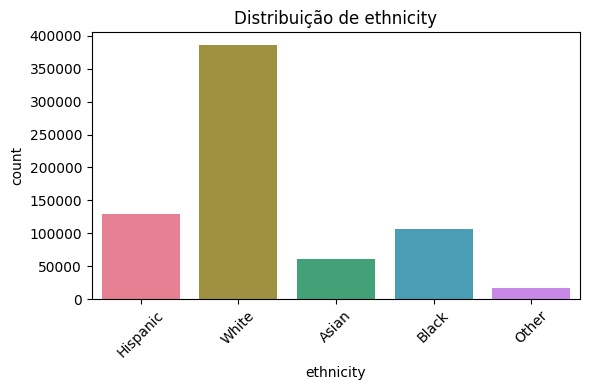

C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_13780\105825291.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=col, palette="husl")


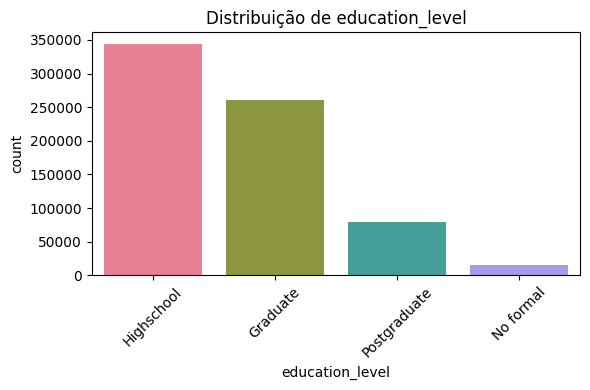

C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_13780\105825291.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=col, palette="husl")


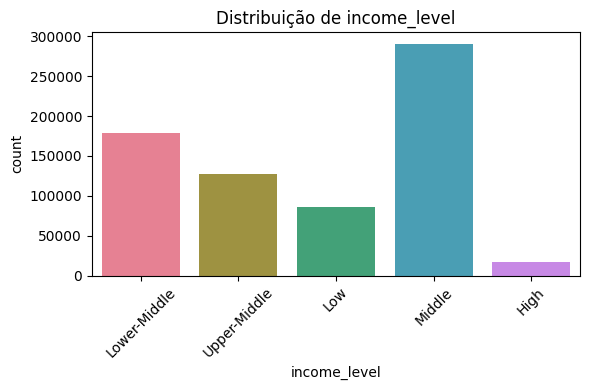

C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_13780\105825291.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=col, palette="husl")


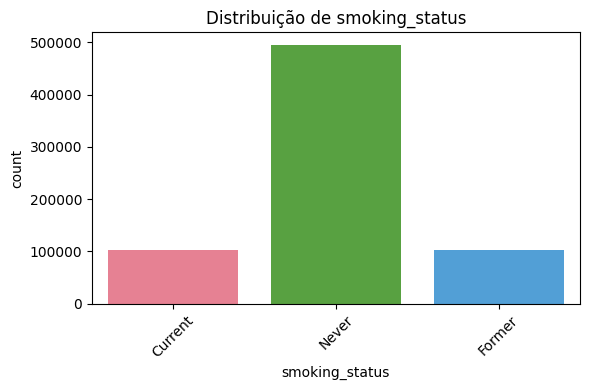

C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_13780\105825291.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=col, palette="husl")


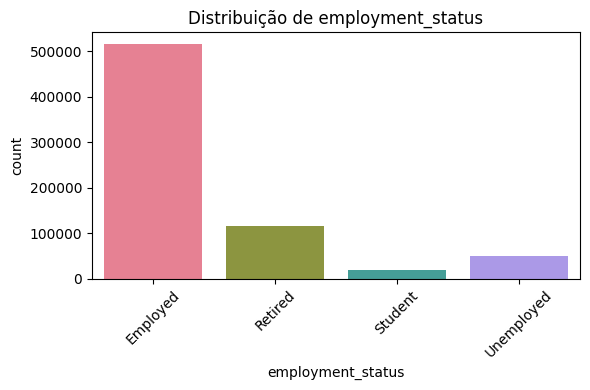

C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_13780\105825291.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=col, palette="husl")


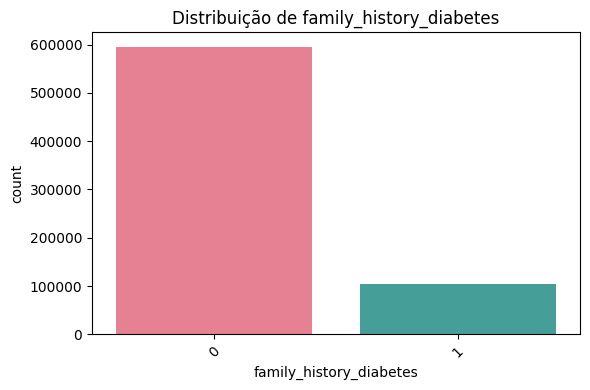

C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_13780\105825291.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=col, palette="husl")


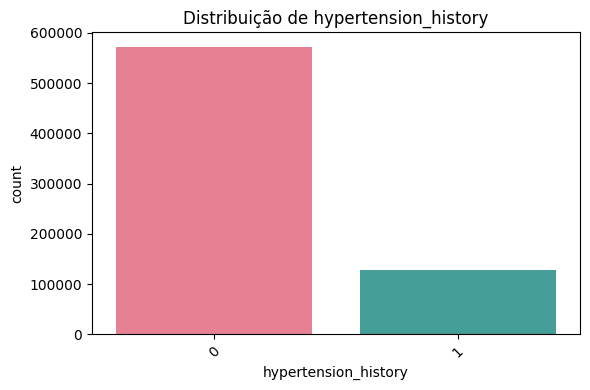

C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_13780\105825291.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=col, palette="husl")


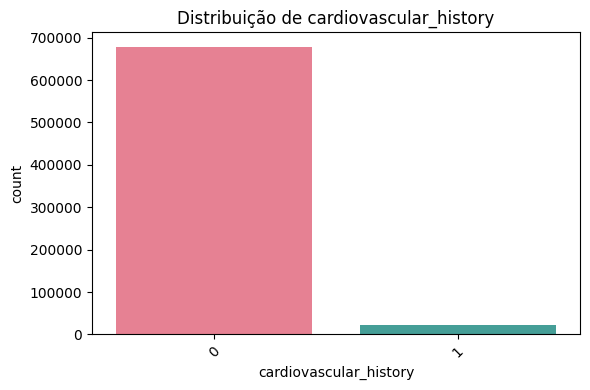

C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_13780\105825291.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=col, palette="husl")


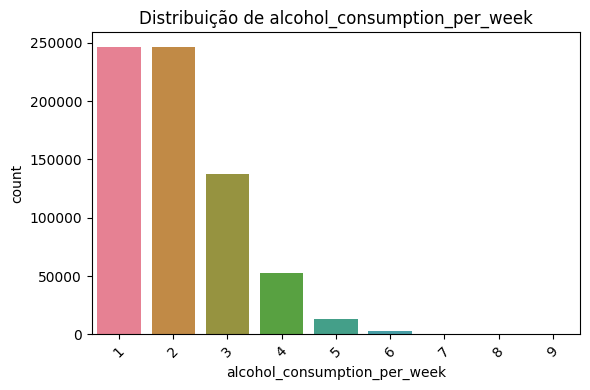

In [72]:
# VISUALIZAÇÃO DAS FEATURES CATEGÓRICAS:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=train_df, x=col, palette="husl")
    plt.title(f"Distribuição de {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_13780\986700111.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=temp.index, y=temp.values, palette="husl")


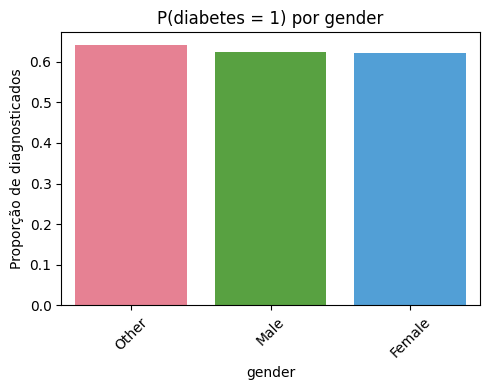

C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_13780\986700111.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=temp.index, y=temp.values, palette="husl")


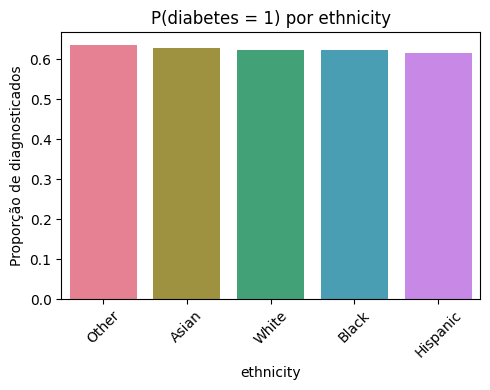

C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_13780\986700111.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=temp.index, y=temp.values, palette="husl")


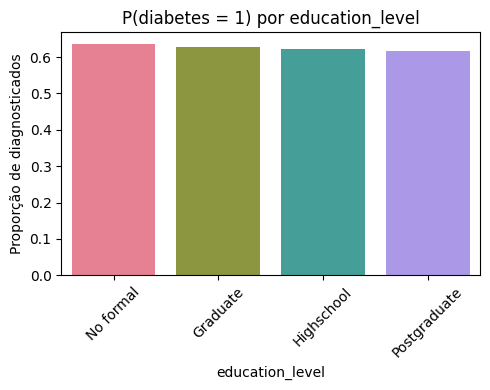

C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_13780\986700111.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=temp.index, y=temp.values, palette="husl")


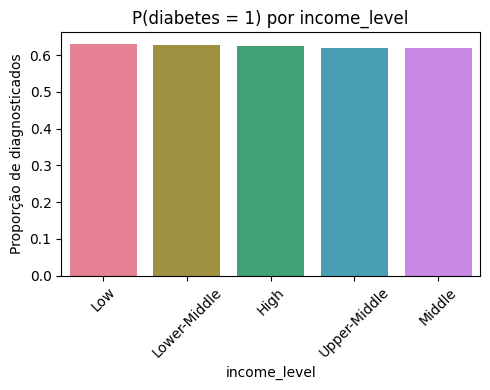

C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_13780\986700111.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=temp.index, y=temp.values, palette="husl")


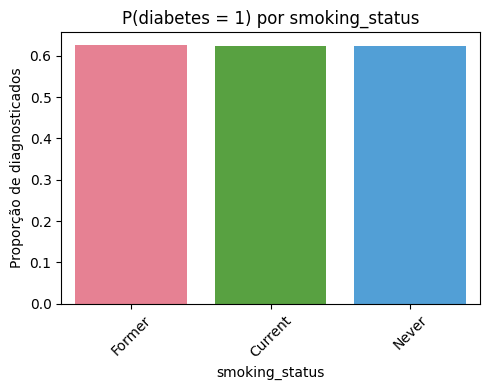

C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_13780\986700111.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=temp.index, y=temp.values, palette="husl")


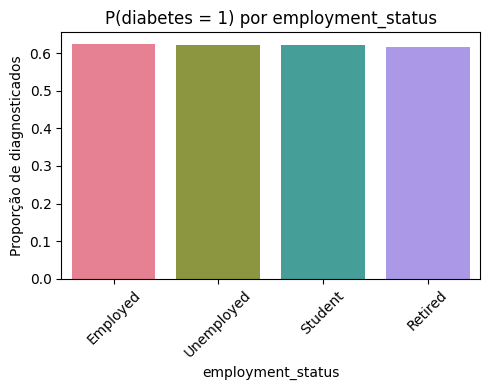

C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_13780\986700111.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=temp.index, y=temp.values, palette="husl")


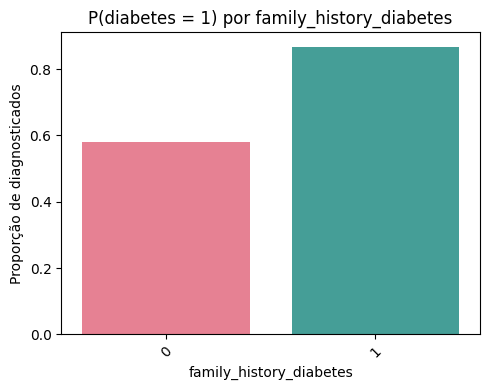

C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_13780\986700111.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=temp.index, y=temp.values, palette="husl")


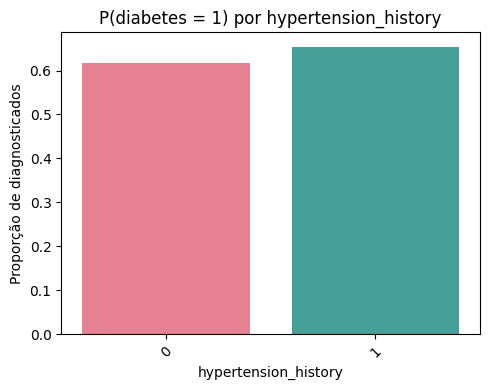

C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_13780\986700111.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=temp.index, y=temp.values, palette="husl")


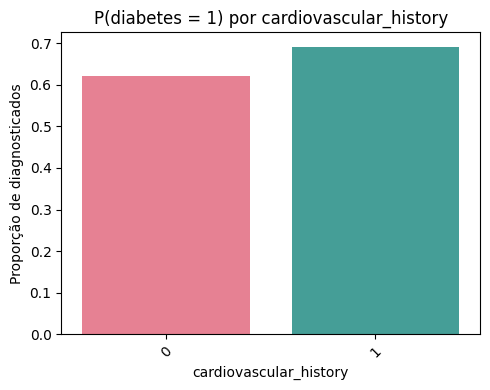

C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_13780\986700111.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=temp.index, y=temp.values, palette="husl")


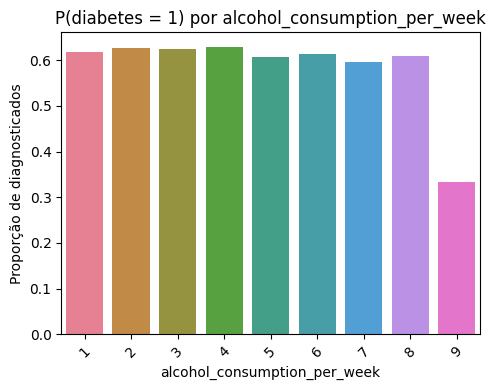

In [77]:
# VISUALIZAÇÃO DA PROPORÇÃO DO TARGET POR CATEGORIA:
def plot_cat_vs_target(col):
    temp = (
        train_df
        .groupby(col)["diagnosed_diabetes"]
        .mean()
        .sort_values(ascending=False)
    )
    plt.figure(figsize=(5,4))
    sns.barplot(x=temp.index, y=temp.values, palette="husl")
    plt.title(f"P(diabetes = 1) por {col}")
    plt.ylabel("Proporção de diagnosticados")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

for col in cat_cols:
    plot_cat_vs_target(col)


* `family_history_diabetes`, `hypertension_history` e `cardiovascular_history`: são claramente as categóricas mais informativas; quem tem histórico familiar de diabetes ou hipertensão tem probabilidade bem maior de diagnóstico de diabetes.

* `alcohol_consumption_per_week`: as categorias 1–8 têm proporções muito parecidas, só a categoria 9 destoa com probabilidade bem menor, o que sugere ou ruído, ou um grupo muito pequeno de indivíduos que bebem muito e estão “seletos” de alguma forma. 

* `gender`, `ethnicity`, `education_level`, `income_level`, `smoking_status`, `employment_status`: visualmente, as barras estão muito próximas entre si; parecem ter pouca variação na probabilidade de diabetes entre categorias.

# 4. MODELAGEM - XGBOOST:

Nesta seção é montado o pipeline de modelagem usando XGBoost, integrando o pré‑processamento (imputação, padronização e one‑hot encoding) por meio de ColumnTransformer e Pipeline. São treinados modelos baseline e avaliadas métricas como AUC e accuracy em um conjunto de validação, servindo como referência inicial antes do ajuste de hiperparâmetros.

## 4.1. PRÉ-PROCESSAMENTO:

In [78]:
# TARGET E FEATURES:
y = train_df["diagnosed_diabetes"]
X = train_df.drop(columns=["diagnosed_diabetes", "id"])

In [79]:
# SPLIT DE TESTE E TREINO ESTRATIFICADO:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# PRE-PROCESSAMENTO DAS FEATURES NUMÉRICAS:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [ ]:
# PRE-PROCESSAMENTO DAS FEATURES CATEGÓRICAS:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [86]:
# COMBINAÇÃO DOS TRANSFORMERS NUMÉRICO E CATEGÓRICO:
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ])

## 4.2. MODELO:

In [88]:
# PIPELINE COM LOGISTIC REGRESSION:
logreg_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000))
])

In [89]:
# PIPELINE COM LOGISTIC REGRESSION:
logreg_pipe.fit(X_train, y_train)
y_pred_log = logreg_pipe.predict(X_valid)
y_proba_log = logreg_pipe.predict_proba(X_valid)[:, 1]

In [90]:
# AVALIAÇÃO DO MODELO DE REGRESSÃO LOGÍSTICA:
print("LogReg AUC:", roc_auc_score(y_valid, y_proba_log))
print("LogReg Acc:", accuracy_score(y_valid, y_pred_log))

LogReg AUC: 0.6948169353956097
LogReg Acc: 0.6643142857142857


LogReg report:
               precision    recall  f1-score   support

         0.0       0.60      0.33      0.43     52739
         1.0       0.68      0.86      0.76     87261

    accuracy                           0.66    140000
   macro avg       0.64      0.60      0.60    140000
weighted avg       0.65      0.66      0.64    140000



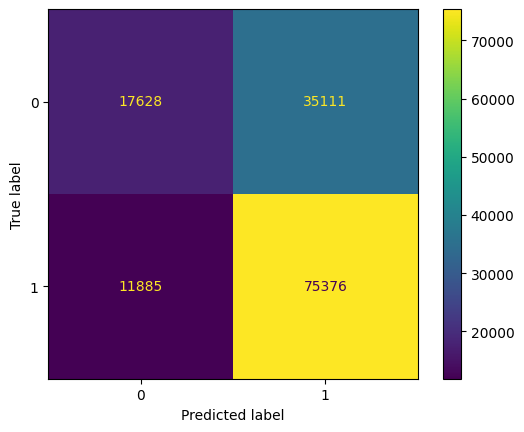

In [95]:
# AVALIAÇÃO DETALHADA DO MODELO DE REGRESSÃO LOGÍSTICA:
print("LogReg report:\n", classification_report(y_valid, y_pred_log))
ConfusionMatrixDisplay(confusion_matrix(y_valid, y_pred_log)).plot()

In [91]:
# XGBOOST CLASSIFIER PIPELINE:
xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

In [92]:
# XGBOOST CLASSIFIER PIPELINE:
xgb_pipe.fit(X_train, y_train)
y_pred_xgb = xgb_pipe.predict(X_valid)
y_proba_xgb = xgb_pipe.predict_proba(X_valid)[:, 1]

In [93]:
# AVALIAÇÃO DO MODELO XGBOOST:
print("XGB AUC:", roc_auc_score(y_valid, y_proba_xgb))
print("XGB Acc:", accuracy_score(y_valid, y_pred_xgb))

XGB AUC: 0.7194069409921039
XGB Acc: 0.6792928571428571


XGB report:
               precision    recall  f1-score   support

         0.0       0.62      0.39      0.48     52739
         1.0       0.70      0.85      0.77     87261

    accuracy                           0.68    140000
   macro avg       0.66      0.62      0.62    140000
weighted avg       0.67      0.68      0.66    140000



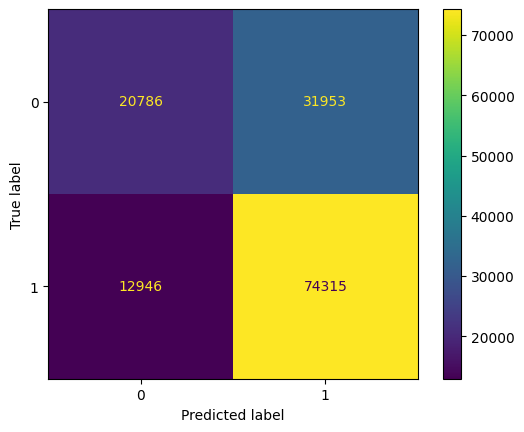

In [96]:
# AVALIAÇÃO DETALHADA DO MODELO XGBOOST:
print("XGB report:\n", classification_report(y_valid, y_pred_xgb))
ConfusionMatrixDisplay(confusion_matrix(y_valid, y_pred_xgb)).plot()

* A **regressão logística** obteve AUC ≈ 0,69 e accuracy ≈ 0,66, com recall alto para diabéticos, mas desempenho fraco para não diabéticos (muitos falsos positivos).

* O **XGBoost** alcançou AUC ≈ 0,72 e accuracy ≈ 0,68, mantendo recall alto para diabéticos e melhorando a precisão e o recall da classe não diabética, resultando em f1‑score ligeiramente superior.

# 5. OTIMIZAÇÃO DO MODELO:

Aqui o modelo XGBoost é refinado por meio de RandomizedSearchCV, buscando melhores combinações de hiperparâmetros com validação cruzada. Em seguida, aplica‑se o balanceamento da classe positiva via scale_pos_weight e é ajustado o threshold de decisão, escolhendo um valor (0,3) que maximiza o f1 da classe positiva e mantém alto recall, adequado ao contexto de saúde.

## 5.1. HIPERPARÂMETROS:

In [99]:
# HYPERPARAMETER TUNING COM RANDOMIZED SEARCH PARA XGBOOST:
param_dist = {
    "model__n_estimators": randint(100, 400),
    "model__max_depth": randint(3, 8),
    "model__learning_rate": uniform(0.01, 0.15),
    "model__subsample": uniform(0.6, 0.4),        
    "model__colsample_bytree": uniform(0.6, 0.4), 
    "model__min_child_weight": randint(1, 6),
    "model__gamma": uniform(0, 0.4),
}

Por existir muitos hiperparâmetros, foi escolhida busca aleatória em vez de grid exaustivo, otimizando roc_auc com validação cruzada.

In [101]:
# RANDOMIZED SEARCH CV:
xgb_random = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=param_dist,
    n_iter=30,              
    scoring="roc_auc",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

In [102]:
# FIT DO RANDOMIZED SEARCH CV:
xgb_random.fit(X_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               Index(['age', 'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'd...
                                        'model__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001B58C9970B0>,
                                        'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001B5964CD400>,
                                        'model__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001B59ADE8F50>},
                   random_state=42, scoring='roc_auc', verbose=1)

In [105]:
print("Melhor AUC (RANDOMSEARCHCV):", xgb_random.best_score_)
print("Melhores parâmetros:")
for k, v in xgb_random.best_params_.items():
    print(f"  {k}: {v}")


Melhor AUC (RANDOMSEARCHCV): 0.7250287786891442
Melhores parâmetros:
  model__colsample_bytree: 0.602208846849441
  model__gamma: 0.3261845713819337
  model__learning_rate: 0.11602860157714256
  model__max_depth: 5
  model__min_child_weight: 3
  model__n_estimators: 388
  model__subsample: 0.8423839899124046


In [107]:
# MODELO OTIMIZADO APÓS RANDOMIZED SEARCH CV:
# UTILIZANDO OS VALORES ENCONTRADOS NO RANDOMIZED SEARCH CV (ÚLTIMA ETAPA):
best_xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBClassifier(
        n_estimators=388,
        max_depth=5,
        learning_rate=0.11602860157714256,
        subsample=0.8423839899124046,
        colsample_bytree=0.602208846849441,
        min_child_weight=3,
        gamma=0.3261845713819337,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

In [108]:
# FIT DO MODELO OTIMIZADO:
best_xgb_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholest...
                               gamma=0.3261845713819337, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.11602860157714256, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=5,
                               max_leaves=None, min_child_weight=3, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=388, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [109]:
# PREDIÇÕES DO MODELO OTIMIZADO:
y_pred_best = best_xgb_pipe.predict(X_valid)
y_proba_best = best_xgb_pipe.predict_proba(X_valid)[:, 1]

Best XGB AUC: 0.7248898252068247
Best XGB Acc: 0.6832928571428571
              precision    recall  f1-score   support

         0.0       0.62      0.42      0.50     52739
         1.0       0.71      0.84      0.77     87261

    accuracy                           0.68    140000
   macro avg       0.66      0.63      0.63    140000
weighted avg       0.67      0.68      0.67    140000



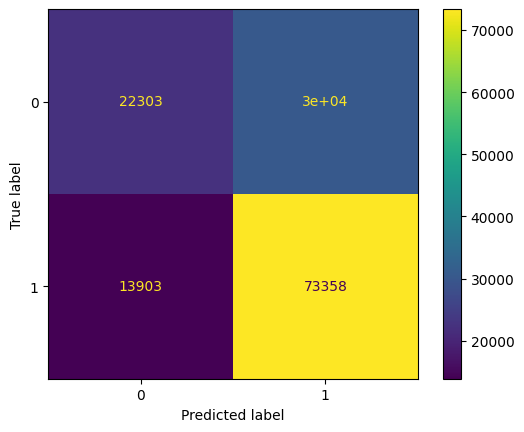

In [111]:
# AVALIAÇÃO DO MODELO OTIMIZADO:
print("Best XGB AUC:", roc_auc_score(y_valid, y_proba_best))
print("Best XGB Acc:", accuracy_score(y_valid, y_pred_best))
print(classification_report(y_valid, y_pred_best))
ConfusionMatrixDisplay(confusion_matrix(y_valid, y_pred_best)).plot()

O ***modelo otimizado com XGBoost*** apresentou desempenho ligeiramente superior em relação às versões anteriores, atingindo **AUC em torno de 0,725 e accuracy próxima de 0,68**. A classe positiva (pacientes com diabetes) manteve recall elevado, ao mesmo tempo em que houve pequena melhora na precisão e no f1‑score, indicando um equilíbrio um pouco melhor entre identificar corretamente os casos de diabetes e reduzir falsos positivos.

In [112]:
# TREINO EM TODO O CONJUNTO DE TREINO:
X_full = train_df.drop(columns=["diagnosed_diabetes", "id"])
y_full = train_df["diagnosed_diabetes"]
best_xgb_pipe.fit(X_full, y_full)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholest...
                               gamma=0.3261845713819337, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.11602860157714256, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=5,
                               max_leaves=None, min_child_weight=3, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=388, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [ ]:
# PREDIÇÕES NO TEST SET:
test_ids = test_df["id"]
X_test = test_df.drop(columns=["id"])
test_proba = best_xgb_pipe.predict_proba(X_test)[:, 1]

In [ ]:
# CRIAÇÃO DO ARQUIVO DE SUBMISSÃO:
test_ids = test_df["id"]
X_test = test_df.drop(columns=["id"])

test_proba = best_xgb_pipe.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    "id": test_ids,
    "diabetes_probability": test_proba
})

submission.to_csv("submission_xgb_best.csv", index=False)


## 5.2. HIPERPARÂMETROS + THRESHOLD + BALANCEAMENTO (SCALE_POS_WEIGHT):

In [115]:
# CÁLCULO DO SCALE_POS_WEIGHT PARA XGBOOST:
neg, pos = np.bincount(y_full)
scale_pos = neg / pos

C:\Users\Yukio Kitamura\AppData\Local\Temp\ipykernel_13780\704577007.py:2: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  neg, pos = np.bincount(y_full)


In [116]:
# MODELO OTIMIZADO APÓS RANDOMIZED SEARCH CV COM BALANCEAMENTO:
best_xgb_pipe_bal = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBClassifier(
        n_estimators=388,
        max_depth=5,
        learning_rate=0.11602860157714256,
        subsample=0.8423839899124046,
        colsample_bytree=0.602208846849441,
        min_child_weight=3,
        gamma=0.3261845713819337,
        scale_pos_weight=scale_pos,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

A base é desbalanceada e esse parâmetro (scale_pos_weight) ajusta o peso da classe positiva diretamente no XGBoost, reduzindo viés sem alterar os dados.

In [117]:
# FIT DO MODELO OTIMIZADO:
best_xgb_pipe_bal.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholest...
                               gamma=0.3261845713819337, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.11602860157714256, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=5,
                               max_leaves=None, min_child_weight=3, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=388, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [118]:
# PREDIÇÕES DO MODELO OTIMIZADO:
y_proba_bal = best_xgb_pipe_bal.predict_proba(X_valid)[:, 1]

In [125]:
# AVALIAÇÃO DO MODELO OTIMIZADO:
thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

for thr in thresholds:
    y_pred_thr = (y_proba_bal >= thr).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_valid, y_pred_thr, average="binary"
    )
    print(f"Threshold {thr}: precision={precision:.3f}, recall={recall:.3f}, f1={f1:.3f}")

Threshold 0.2: precision=0.638, recall=0.988, f1=0.775
Threshold 0.25: precision=0.652, recall=0.968, f1=0.779
Threshold 0.3: precision=0.671, recall=0.932, f1=0.780
Threshold 0.35: precision=0.693, recall=0.878, f1=0.774
Threshold 0.4: precision=0.719, recall=0.807, f1=0.760
Threshold 0.45: precision=0.746, recall=0.726, f1=0.736
Threshold 0.5: precision=0.775, recall=0.631, f1=0.695


Foi realizado um ajuste do limiar de decisão do modelo a partir das probabilidades previstas, avaliando diferentes valores de threshold entre 0,2 e 0,5. Observou-se que o limiar de **`0,3` oferece o melhor equilíbrio entre precisão (0,671) e recall (0,932) para a classe positiva, resultando no maior f1-score (0,780) dentre os valores testados**. Nesse contexto de saúde, em que é prioritário não deixar de identificar pacientes com diabetes, a escolha de **`0,3`** é adequada por manter um recall muito elevado, ao mesmo tempo em que controla a quantidade de falsos positivos em um nível considerado aceitável.

In [126]:
# FIT DO MODELO OTIMIZADO:
X_full = train_df.drop(columns=["diagnosed_diabetes", "id"])
y_full = train_df["diagnosed_diabetes"]

best_xgb_pipe_bal.fit(X_full, y_full)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholest...
                               gamma=0.3261845713819337, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.11602860157714256, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=5,
                               max_leaves=None, min_child_weight=3, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=388, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [127]:
# PREDIÇÕES NO TEST SET:
test_ids = test_df["id"]
X_test = test_df.drop(columns=["id"])

test_proba = best_xgb_pipe_bal.predict_proba(X_test)[:, 1]

In [ ]:
test_pred = (test_proba >= 0.3).astype(int)

In [ ]:
# CRIAÇÃO DO ARQUIVO DE SUBMISSÃO:
submission = pd.DataFrame({
    "id": test_ids,
    "diabetes_probability": test_proba
})
submission.to_csv("submission_xgb_best_balanced.csv", index=False)


In [134]:
# PREDIÇÕES DO MODELO OTIMIZADO:
y_proba_bal = best_xgb_pipe_bal.predict_proba(X_valid)[:, 1]
y_pred_05 = (y_proba_bal >= 0.5).astype(int)   # threshold padrão
y_pred_03 = (y_proba_bal >= 0.3).astype(int)   # threshold escolhido

# AVALIAÇÃO DO MODELO OTIMIZADO:
print("AUC:", roc_auc_score(y_valid, y_proba_bal))
print("Acc (0.5):", accuracy_score(y_valid, y_pred_05))
print("Acc (0.3):", accuracy_score(y_valid, y_pred_03))

print("\nRelatório (threshold 0.3):")
print(classification_report(y_valid, y_pred_03))

AUC: 0.7386480760078247
Acc (0.5): 0.6644214285714286
Acc (0.3): 0.6785571428571429

Relatório (threshold 0.3):
              precision    recall  f1-score   support

         0.0       0.70      0.25      0.37     52739
         1.0       0.67      0.94      0.78     87261

    accuracy                           0.68    140000
   macro avg       0.69      0.59      0.58    140000
weighted avg       0.69      0.68      0.63    140000



# 6. CONCLUSÕES E ETAPAS FUTURAS:

- O melhor modelo obtido foi um **XGBoost otimizado**, com tuning via `RandomizedSearchCV`, balanceamento da classe positiva com `scale_pos_weight` e ajuste de limiar de decisão (threshold) em 0,3.  
- No conjunto de validação, o modelo alcançou **AUC em torno de 0,72** e **accuracy próxima de 0,68**, com **recall elevado para a classe positiva** (diabéticos) e bom f1‑score após o ajuste de threshold, atendendo ao objetivo de priorizar a identificação de pacientes com maior risco.  
- As features mais importantes incluem variáveis clínicas e de estilo de vida, como **idade, IMC, pressão sistólica, histórico familiar de diabetes, hipertensão e nível de atividade física**, em linha com o que foi observado na análise exploratória de dados.  
- Como próximos passos, seria possível investir em **feature engineering** (criação de faixas de idade/IMC, interações entre condições clínicas), testar outros algoritmos de gradient boosting (como LightGBM ou CatBoost) e explorar técnicas de interpretação de modelos (por exemplo, SHAP) para aprofundar o entendimento das previsões.